<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-spice-consumption-trends-ml-99-12?scriptVersionId=232414291" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-spice-consumption/Export.csv


## Title: Global Spice Consumption Trends

#### Description: Explore worldwide spice consumption patterns, highlighting popular spices, regional preferences, and emerging culinary trends.

### Impor dataset

In [2]:
df = pd.read_csv('/kaggle/input/global-spice-consumption/Export.csv')

In [3]:
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Item Code (CPC),Item,Year,Unit,Import,Export,Production,Consumption
0,TCL,Crops and livestock products,4,Afghanistan,5610,1654,"Anise, badian, coriander, cumin, caraway, fenn...",2014,t,283.85,21099.0,21500.00,684.85
1,TCL,Crops and livestock products,4,Afghanistan,5610,1654,"Anise, badian, coriander, cumin, caraway, fenn...",2015,t,1000.16,17340.0,18000.00,1660.16
2,TCL,Crops and livestock products,4,Afghanistan,5610,1654,"Anise, badian, coriander, cumin, caraway, fenn...",2016,t,814.88,8353.0,17333.33,9795.21
3,TCL,Crops and livestock products,4,Afghanistan,5610,1654,"Anise, badian, coriander, cumin, caraway, fenn...",2017,t,3.67,8500.0,18234.12,9737.79
4,TCL,Crops and livestock products,4,Afghanistan,5610,1654,"Anise, badian, coriander, cumin, caraway, fenn...",2018,t,112.30,9456.0,17855.82,8512.12


In [4]:
df.tail()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Item Code (CPC),Item,Year,Unit,Import,Export,Production,Consumption
45316,TCL,Crops and livestock products,716,Zimbabwe,5610,1658,"Vanilla, raw",2014,t,0.04,0.0,10.09,10.13
45317,TCL,Crops and livestock products,716,Zimbabwe,5610,1658,"Vanilla, raw",2015,t,0.10,0.0,10.11,10.21
45318,TCL,Crops and livestock products,716,Zimbabwe,5610,1658,"Vanilla, raw",2016,t,0.01,0.0,9.73,9.74
45319,TCL,Crops and livestock products,716,Zimbabwe,5610,1658,"Vanilla, raw",2019,t,0.02,0.0,9.88,9.90
45320,TCL,Crops and livestock products,716,Zimbabwe,5610,1658,"Vanilla, raw",2023,t,0.12,0.0,9.92,10.04


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45321 entries, 0 to 45320
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Domain Code      45321 non-null  object 
 1   Domain           45321 non-null  object 
 2   Area Code (M49)  45321 non-null  int64  
 3   Area             45321 non-null  object 
 4   Element Code     45321 non-null  int64  
 5   Item Code (CPC)  45321 non-null  int64  
 6   Item             45321 non-null  object 
 7   Year             45321 non-null  int64  
 8   Unit             45321 non-null  object 
 9   Import           45321 non-null  float64
 10  Export           45321 non-null  float64
 11  Production       45321 non-null  float64
 12  Consumption      45321 non-null  float64
dtypes: float64(4), int64(4), object(5)
memory usage: 4.5+ MB


In [6]:
df.describe()

,Area Code (M49),Element Code,Item Code (CPC),Year,Import,Export,Production,Consumption
count,45321.000000,45321.0,45321.000000,45321.000000,4.532100e+04,4.532100e+04,4.532100e+04,4.532100e+04
mean,422.784824,5610.0,1611.224333,2009.062267,2.979475e+03,3.304097e+03,3.088251e+04,3.055789e+04
std,252.530226,0.0,128.138020,8.784068,2.463151e+04,3.111707e+04,4.981218e+05,4.939798e+05
min,4.000000,5610.0,1231.000000,1993.000000,0.000000e+00,0.000000e+00,0.000000e+00,-5.009568e+04
25%,203.000000,5610.0,1652.000000,2002.000000,3.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
50%,410.000000,5610.0,1654.000000,2009.000000,5.090000e+01,1.000000e+00,0.000000e+00,8.223000e+01
75%,642.000000,5610.0,1656.000000,2017.000000,5.396500e+02,7.480000e+01,0.000000e+00,1.113050e+03
max,894.000000,5610.0,1658.000000,2023.000000,1.334022e+06,1.220169e+06,1.734695e+07,1.732090e+07


In [7]:
df.shape

(45321, 13)

In [8]:
df.isnull().sum()

Domain Code        0
Domain             0
Area Code (M49)    0
Area               0
Element Code       0
Item Code (CPC)    0
Item               0
Year               0
Unit               0
Import             0
Export             0
Production         0
Consumption        0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

Domain Code         object
Domain              object
Area Code (M49)      int64
Area                object
Element Code         int64
Item Code (CPC)      int64
Item                object
Year                 int64
Unit                object
Import             float64
Export             float64
Production         float64
Consumption        float64
dtype: object

In [11]:
df.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Item Code (CPC)', 'Item', 'Year', 'Unit', 'Import', 'Export ',
       'Production', 'Consumption'],
      dtype='object')

## data visualizations

In [12]:
# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Clean up column names (remove trailing spaces)
df.columns = df.columns.str.strip()


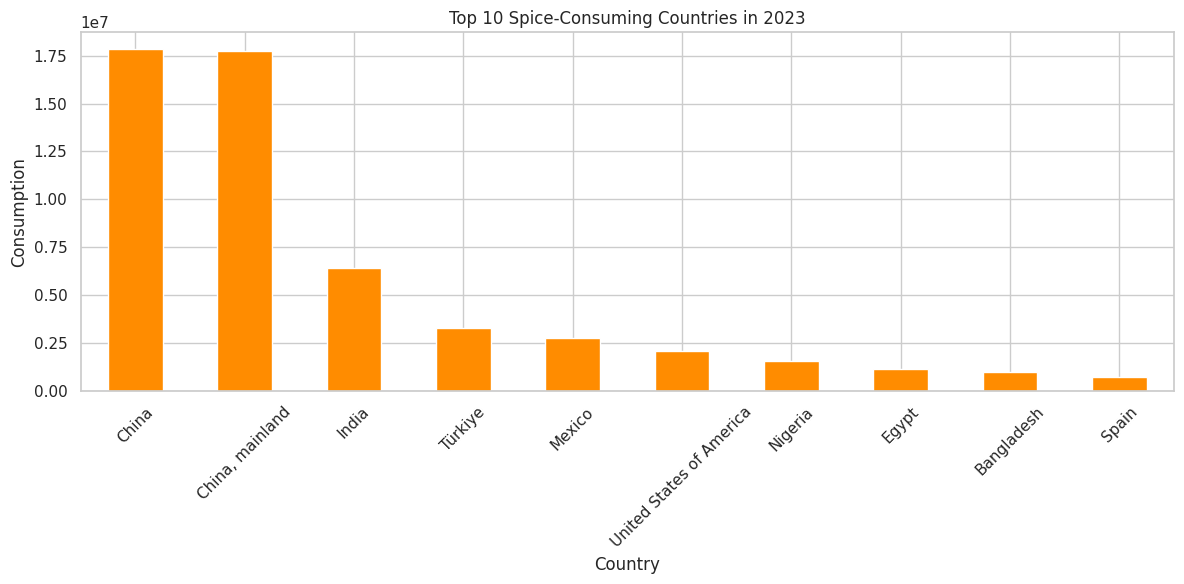

In [13]:
# Filter for latest year
latest_year = df['Year'].max()
latest_df = df[df['Year'] == latest_year]

# Group by Area and sum the consumption
top_countries = latest_df.groupby('Area')['Consumption'].sum().sort_values(ascending=False).head(10)

# Plot
top_countries.plot(kind='bar', color='darkorange')
plt.title(f"Top 10 Spice-Consuming Countries in {latest_year}")
plt.ylabel("Consumption")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


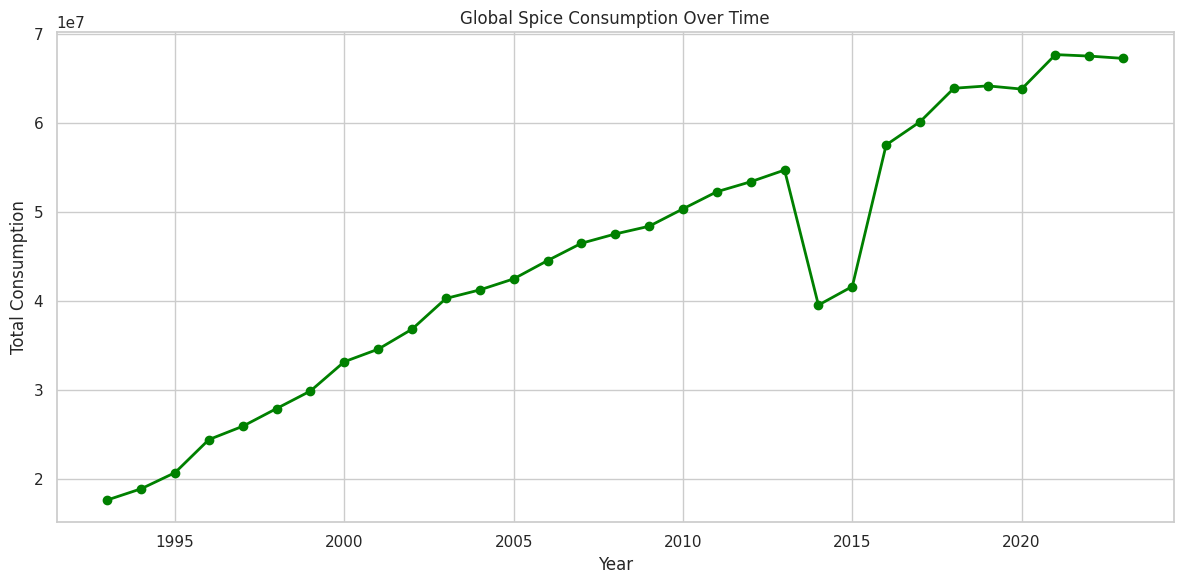

In [14]:
# Group by Year and sum consumption
yearly_consumption = df.groupby('Year')['Consumption'].sum()

# Plot
yearly_consumption.plot(marker='o', linewidth=2, color='green')
plt.title("Global Spice Consumption Over Time")
plt.ylabel("Total Consumption")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()


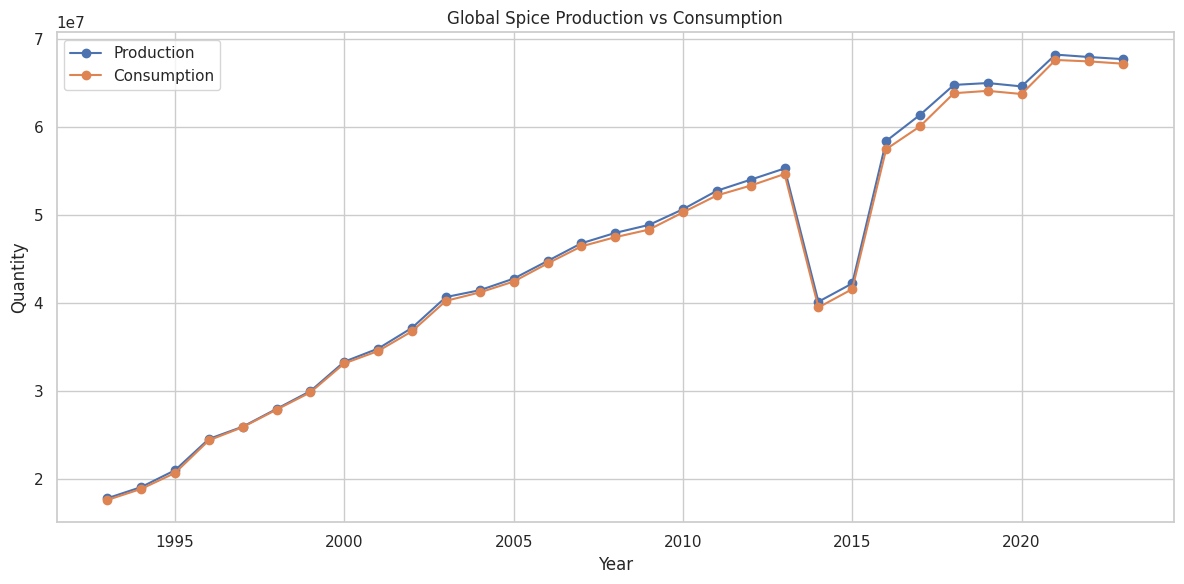

In [15]:
# Group by year
prod_cons = df.groupby('Year')[['Production', 'Consumption']].sum()

# Plot
prod_cons.plot(kind='line', marker='o')
plt.title("Global Spice Production vs Consumption")
plt.ylabel("Quantity")
plt.xlabel("Year")
plt.legend(["Production", "Consumption"])
plt.grid(True)
plt.tight_layout()
plt.show()


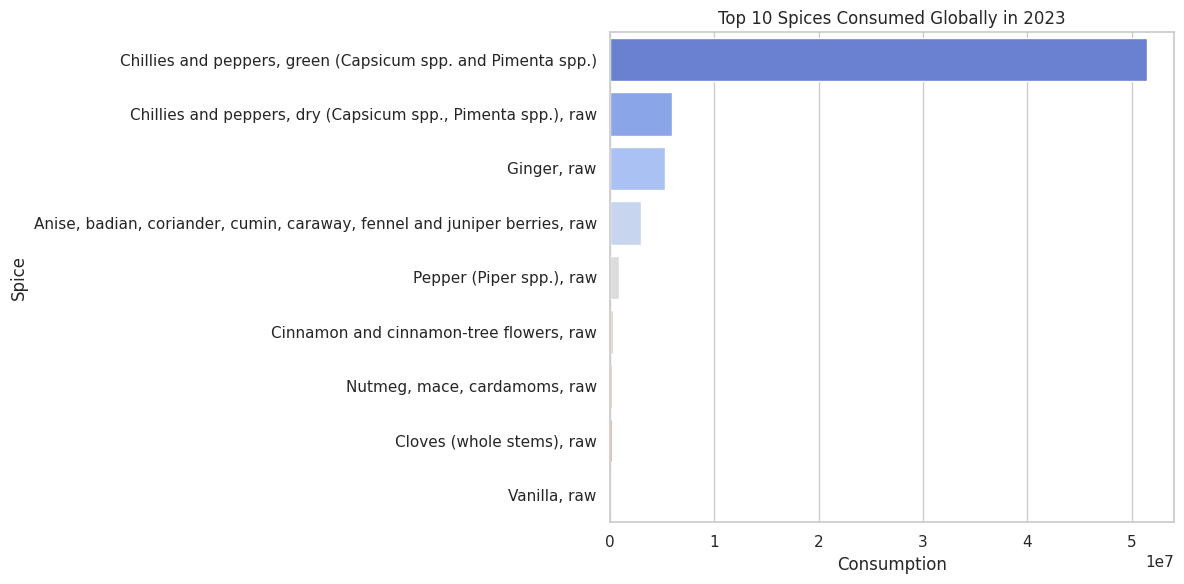

In [16]:
# Group by Item
top_spices = latest_df.groupby('Item')['Consumption'].sum().sort_values(ascending=False).head(10)

# Plot
sns.barplot(x=top_spices.values, y=top_spices.index, palette='coolwarm')
plt.title(f"Top 10 Spices Consumed Globally in {latest_year}")
plt.xlabel("Consumption")
plt.ylabel("Spice")
plt.tight_layout()
plt.show()


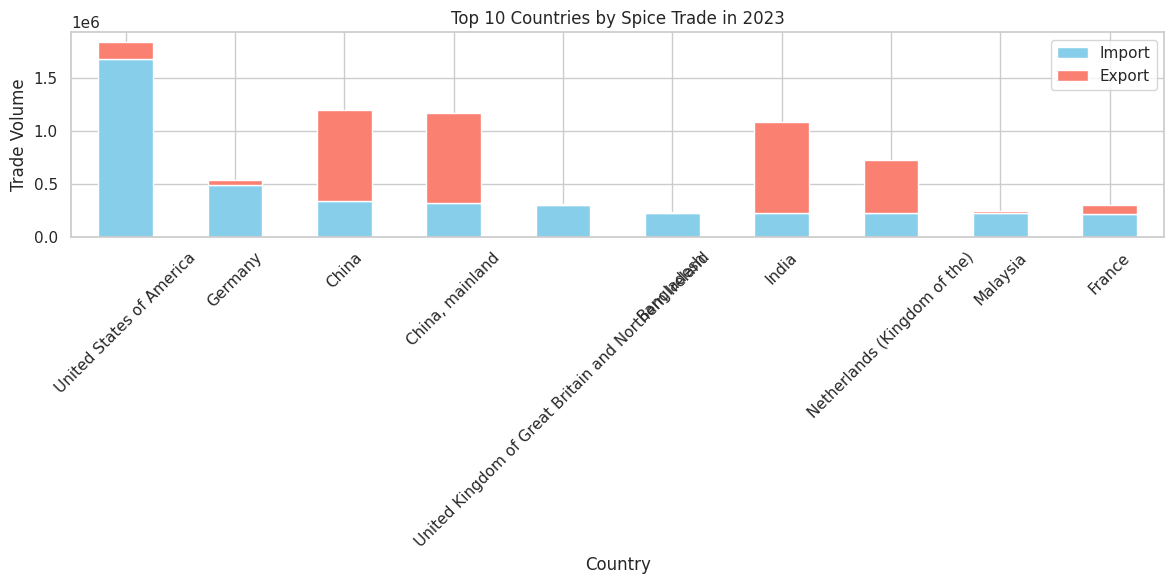

In [17]:
# Get top 10 countries by total trade (import + export)
latest_df['Total Trade'] = latest_df['Import'] + latest_df['Export']
top_trade = latest_df.groupby('Area')[['Import', 'Export']].sum().sort_values(by='Import', ascending=False).head(10)

# Plot
top_trade.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title(f"Top 10 Countries by Spice Trade in {latest_year}")
plt.ylabel("Trade Volume")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [19]:
# Clean column names
df.columns = df.columns.str.strip()

# Drop rows with missing values in important columns
df = df.dropna(subset=['Consumption', 'Import', 'Export', 'Production'])

# Create target column: High (1) if consumption > median, else Low (0)
df['Target'] = (df['Consumption'] > df['Consumption'].median()).astype(int)

# Features we'll use
features = ['Area', 'Item', 'Year', 'Import', 'Export', 'Production']
X = df[features]
y = df['Target']


In [20]:
le_area = LabelEncoder()
le_item = LabelEncoder()

X['Area'] = le_area.fit_transform(X['Area'])
X['Item'] = le_item.fit_transform(X['Item'])


In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train[['Import', 'Export', 'Production']] = scaler.fit_transform(X_train[['Import', 'Export', 'Production']])
X_test[['Import', 'Export', 'Production']] = scaler.transform(X_test[['Import', 'Export', 'Production']])



Logistic Regression - Accuracy: 74.42%


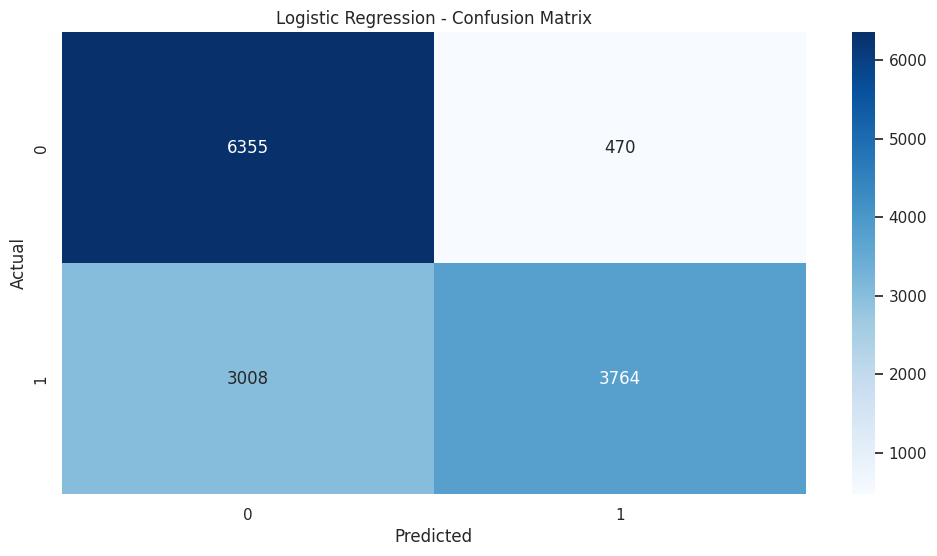


Random Forest - Accuracy: 99.14%


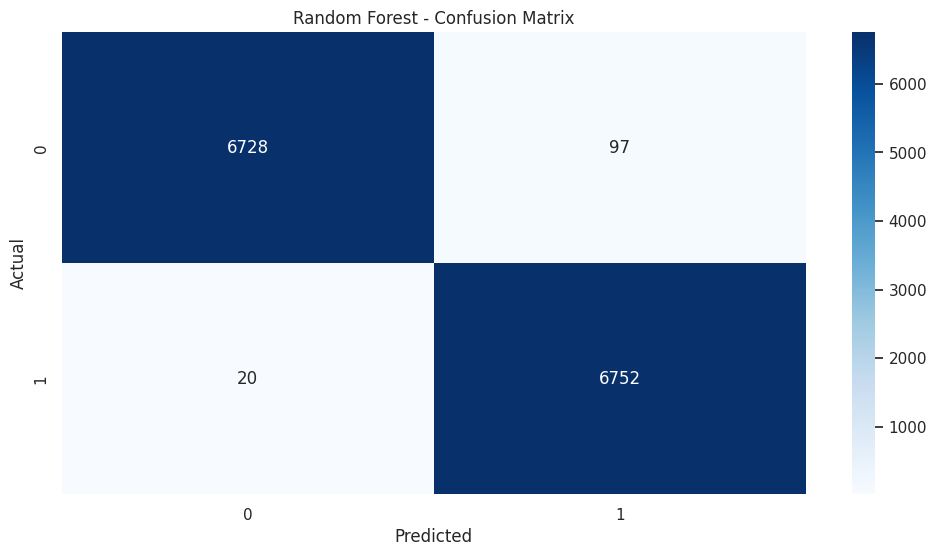


Support Vector Machine - Accuracy: 51.36%


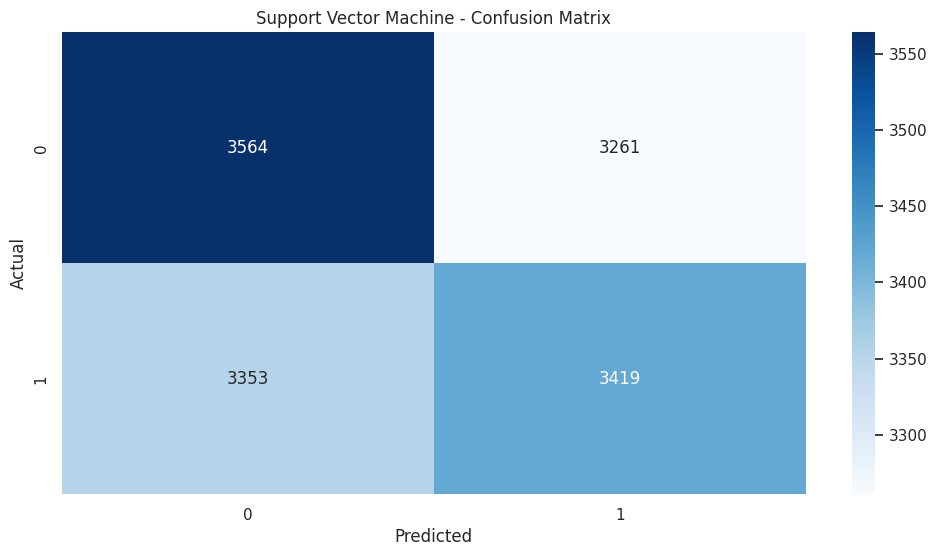


Decision Tree - Accuracy: 98.82%


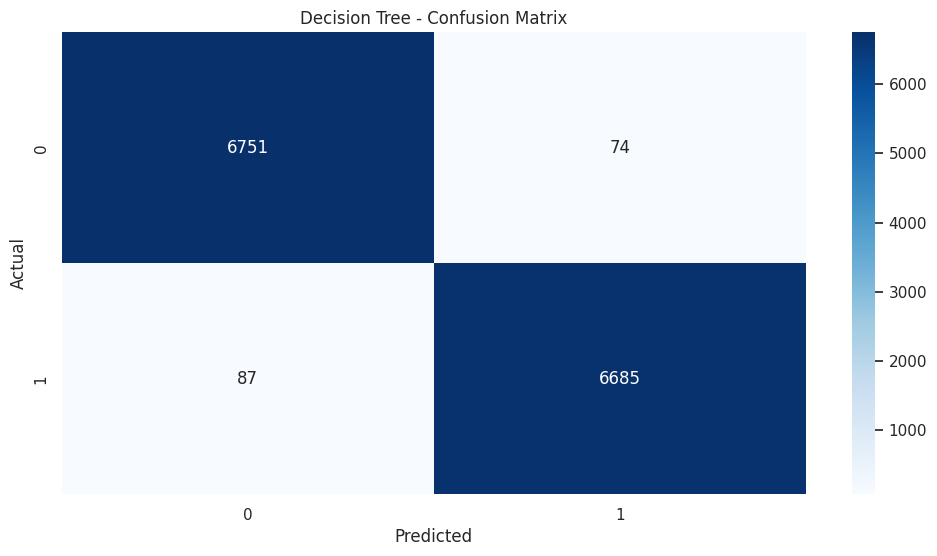


K-Nearest Neighbors - Accuracy: 82.68%


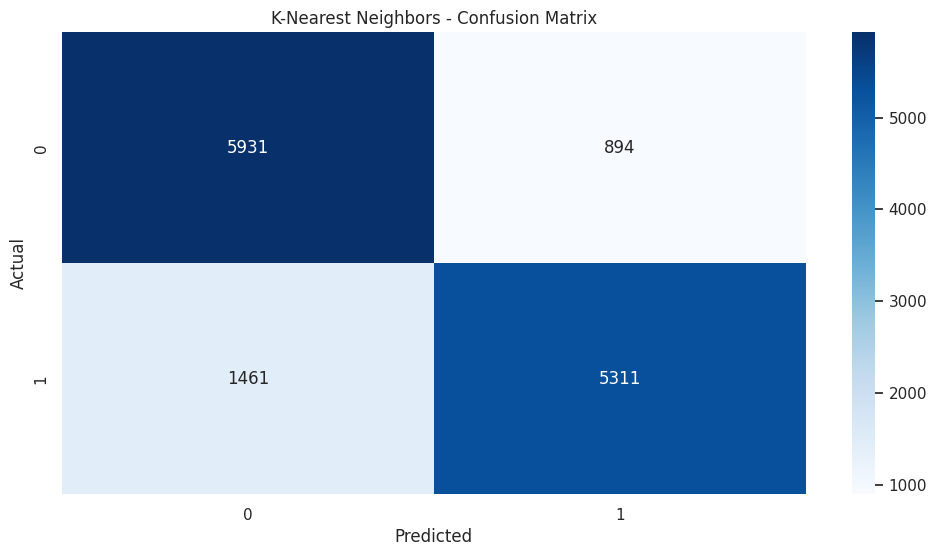

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = round(acc * 100, 2)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name} - Accuracy: {acc*100:.2f}%")
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


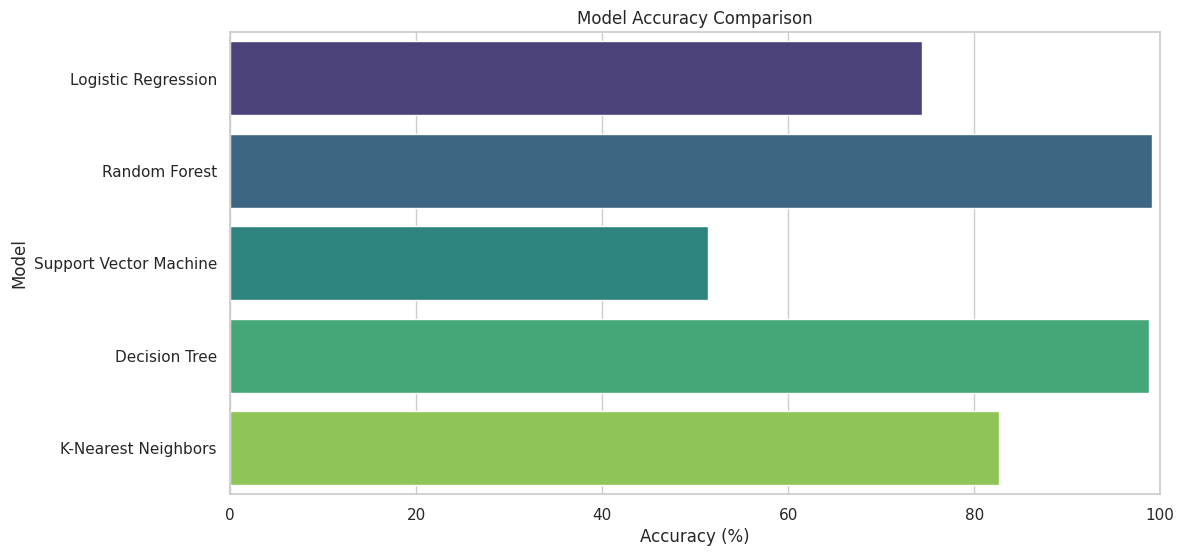

In [23]:
# Accuracy bar chart
acc_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy (%)'])
sns.barplot(x='Accuracy (%)', y='Model', data=acc_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.xlim(0, 100)
plt.show()


## Thank you...pls upvote!!!!